# EDA: Calima vs Deaths — La Palma

**Objective:** Analyze the association between calima (proxy) and weekly mortality in La Palma, including lagged effects (lag0, lag1, lag2).

**Key variables:**
- `deaths_week`: weekly deaths (2016–2025)
- `calima_proxy_score`: heuristic index (0–4.5)
- `calima_proxy_level`: category (no_calima / possible / probable / intense)

**Sections:**
1. Load data
2. Lag0, lag1, lag2 correlations
3. Group by proxy category
4. Significant differences (ANOVA) and effect sizes (Δ deaths)
4.1 Pairwise comparisons
5. Visualizations
6. Summary

---

## 1. Load Data

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# ─── ISLAND CONFIG ─────────────────────────────────────────────────────────────
ISLAND_NAME = "la_palma"   # e.g. "gran_canaria", "tenerife", "lanzarote"
ISLAND_CODE = "lpa"   # e.g. "gcan", "tfe", "lanz"
# ───────────────────────────────────────────────────────────────────────────────

CWD = Path.cwd().resolve()

# If running from islands/<island>, go up two levels to repo root
if CWD.name == ISLAND_NAME and CWD.parent.name == "islands":
    ROOT = CWD.parent.parent
else:
    ROOT = CWD

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("CWD :", CWD)
print("ROOT:", ROOT)
print("src exists?:", (ROOT / "src").exists())

from src.utils.d25_nb_utils import (
    section, glance, checks, missing_table, num_summary,
    autosave_fig, save_table,
)

# Output directories
REPORTS_DIR = ROOT / "reports" / "islands"
FIG_DIR = REPORTS_DIR / "figures" / ISLAND_NAME
TAB_DIR = REPORTS_DIR / "tables" / ISLAND_NAME

FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

print("FIG_DIR:", FIG_DIR)
print("TAB_DIR:", TAB_DIR)

# Load master dataset
FP = ROOT / "data/processed" / ISLAND_NAME / "master" / f"master_{ISLAND_CODE}_2016_2025.parquet"
print("FP:", FP)
assert FP.exists(), f"Missing file: {FP}"

section(f"EDA core weekly {ISLAND_NAME}")

df = pd.read_parquet(FP)
print("Loaded:", FP)

df["week_start"] = pd.to_datetime(df["week_start"], errors="coerce")
print("Week range:", df["week_start"].min(), "->", df["week_start"].max())
glance(df, label=f"eda_core_weekly_{ISLAND_CODE}", n=5)

checks(
    df,
    required=["week_start", "deaths_week"],
    key=["week_start"],
    dt="week_start"
)

num_summary(df)

# Load calima proxy dataset
calima_fp = ROOT / "data" / "processed" / ISLAND_NAME / "calima" / f"calima_proxy_weekly_{ISLAND_CODE}_2016_2025.parquet"
print("Calima proxy FP:", calima_fp)

if calima_fp.exists():
    calima = pd.read_parquet(calima_fp).copy()
    calima["week_start"] = pd.to_datetime(calima["week_start"], errors="coerce")
    keep = [
        "week_start",
        "calima_proxy_score",
        "calima_proxy_level",
    ]

    calima_keep = [c for c in keep if c in calima.columns]

    # Drop overlapping columns before merge to avoid duplicates
    overlap = [c for c in calima_keep if c != "week_start" and c in df.columns]
    if overlap:
        print("Dropping overlapping columns before merge:", overlap)
        df = df.drop(columns=overlap)

    df = df.merge(calima[calima_keep], on="week_start", how="left")
    print("Merged calima proxy columns:", [c for c in calima_keep if c != "week_start"])
else:
    print("Calima proxy weekly dataset not found. Section 6.1 will be skipped.")

print("Final shape:", df.shape)

CWD : C:\Users\fdora\RA_Career\Projects\climate_mortality\islands\la_palma
ROOT: C:\Users\fdora\RA_Career\Projects\climate_mortality
src exists?: True
FIG_DIR: C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\islands\figures\la_palma
TAB_DIR: C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\islands\tables\la_palma
FP: C:\Users\fdora\RA_Career\Projects\climate_mortality\data\processed\la_palma\master\master_lpa_2016_2025.parquet

EDA core weekly la_palma
Loaded: C:\Users\fdora\RA_Career\Projects\climate_mortality\data\processed\la_palma\master\master_lpa_2016_2025.parquet
Week range: 2015-12-28 00:00:00 -> 2025-12-29 00:00:00

--- eda_core_weekly_lpa ---
shape: (523, 42)

dtypes:
 week_start                     datetime64[ns]
year                                    int32
island                                 object
island_code                            object
deaths_week                           float64
deaths_missing_week                   float64
n_days       

,week_start,year,island,island_code,deaths_week,deaths_missing_week,n_days,temp_c_mean,tmax_c_mean,tmax_c_max,...,O3,days_with_pm10,days_missing_pm10,cap_heat_level_max_week,cap_dust_level_max_week,cap_heat_yellow_plus_week,cap_dust_yellow_plus_week,cap_coverage_week,calima_dai_flag,calima_level_week
0,2015-12-28,2015,la_palma,lpa,NaN,NaN,3,18.933333,21.966667,22.2,...,71.333333,3,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0
1,2016-01-04,2016,la_palma,lpa,17.0,0.0,7,19.314286,21.957143,23.9,...,77.000000,7,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0
2,2016-01-11,2016,la_palma,lpa,22.0,0.0,7,20.371429,23.085714,23.6,...,68.428571,7,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0
3,2016-01-18,2016,la_palma,lpa,12.0,0.0,7,19.828571,22.985714,25.4,...,70.571429,7,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0
4,2016-01-25,2016,la_palma,lpa,13.0,0.0,7,19.800000,22.371429,23.8,...,82.571429,7,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0


Calima proxy FP: C:\Users\fdora\RA_Career\Projects\climate_mortality\data\processed\la_palma\calima\calima_proxy_weekly_lpa_2016_2025.parquet
Merged calima proxy columns: ['calima_proxy_score', 'calima_proxy_level']
Final shape: (523, 44)


## 2. Lags

In [2]:
# Filter out the first partial week (null deaths)
first_week = df['week_start'].min()
df = df[df['week_start'] > first_week].reset_index(drop=True)

print(f"Rows after filtering first week: {len(df)}")
print(f"Deaths nulls: {df['deaths_week'].isna().sum()}")
print(f"Calima proxy score nulls: {df['calima_proxy_score'].isna().sum()}")

# Create lag variables for calima_proxy_score
df['calima_proxy_score_lag1'] = df['calima_proxy_score'].shift(1)
df['calima_proxy_score_lag2'] = df['calima_proxy_score'].shift(2)

print("\n✅ Lag variables created:")
print(f"  lag0 (contemporaneous): {df['calima_proxy_score'].notna().sum()} non-null")
print(f"  lag1 (1 week prior):    {df['calima_proxy_score_lag1'].notna().sum()} non-null")
print(f"  lag2 (2 weeks prior):   {df['calima_proxy_score_lag2'].notna().sum()} non-null")

Rows after filtering first week: 522
Deaths nulls: 0
Calima proxy score nulls: 0

✅ Lag variables created:
  lag0 (contemporaneous): 522 non-null
  lag1 (1 week prior):    521 non-null
  lag2 (2 weeks prior):   520 non-null


In [4]:
# Correlations: deaths_week vs calima_proxy_score at different lags
corr_lag0 = df['deaths_week'].corr(df['calima_proxy_score'])
corr_lag1 = df['deaths_week'].corr(df['calima_proxy_score_lag1'])
corr_lag2 = df['deaths_week'].corr(df['calima_proxy_score_lag2'])

corr_summary = pd.DataFrame({
    'lag': ['lag0 (same week)', 'lag1 (1 week prior)', 'lag2 (2 weeks prior)'],
    'correlation': [corr_lag0, corr_lag1, corr_lag2],
    'n_pairs': [
        df[['deaths_week', 'calima_proxy_score']].notna().all(axis=1).sum(),
        df[['deaths_week', 'calima_proxy_score_lag1']].notna().all(axis=1).sum(),
        df[['deaths_week', 'calima_proxy_score_lag2']].notna().all(axis=1).sum(),
    ]
})

print("Correlations: deaths_week vs calima_proxy_score\n")
print(corr_summary.to_string(index=False))

# Save
corr_summary.to_csv(TAB_DIR / 'calima_deaths_lags_correlation.csv', index=False)
print("\n✅ Saved: calima_deaths_lags_correlation.csv")

Correlations: deaths_week vs calima_proxy_score

                 lag  correlation  n_pairs
    lag0 (same week)     0.100958      522
 lag1 (1 week prior)     0.040999      521
lag2 (2 weeks prior)     0.117117      520

✅ Saved: calima_deaths_lags_correlation.csv


**Interpretation — Lag Correlations**

Strongest correlation: lag2 (r = 0.117), marginally above lag0 (r = 0.101). This suggests a weak delayed effect — calima exposure may precede a slight mortality increase with a two-week lag. However, the difference between lag0 and lag2 is minimal (Δr = 0.016), making it difficult to distinguish a same-week effect from a delayed one. All correlations remain weak, explaining less than 1.4% of variance in weekly deaths.

---


## 3. Group by Proxy Category

In [9]:
# Group by calima_proxy_level and compute deaths statistics
level_order = ['no_calima', 'possible', 'probable', 'intense']

deaths_by_level = (
    df.groupby('calima_proxy_level', observed=True)['deaths_week']
    .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
    .reindex(level_order)
)

print("Deaths statistics by calima proxy level:\n")
print(deaths_by_level.round(2))

# Compute Δ deaths (intense vs baseline)
baseline = deaths_by_level.loc['no_calima', 'mean']
intense  = deaths_by_level.loc['intense', 'mean']
delta    = intense - baseline

print(f"\nΔ deaths (intense vs no_calima): {delta:.2f} deaths/week")

# Save
deaths_by_level.to_csv(TAB_DIR / 'calima_level_v_deaths_stats.csv')
print("\n✅ Saved: calima_level_v_deaths_stats.csv")

Deaths statistics by calima proxy level:

                    count   mean  median   std  min   max
calima_proxy_level                                       
no_calima             316  15.64    15.0  4.35  6.0  30.0
possible              159  15.87    15.0  5.10  5.0  48.0
probable               27  16.37    16.0  5.63  7.0  31.0
intense                20  17.40    16.0  6.05  9.0  31.0

Δ deaths (intense vs no_calima): 1.76 deaths/week

✅ Saved: calima_level_v_deaths_stats.csv



**Interpretation — Deaths by Calima Proxy Level**

The relationship is monotonic: mean deaths increase consistently from `no_calima` (15.64) through `possible` (15.87) and `probable` (16.37) to `intense` (17.40). This is the clearest dose-response pattern observed across the islands analyzed so far. The Δ of +1.76 deaths/week at the extreme tier, combined with the consistent gradient across all tiers, is consistent with a progressive calima-mortality association rather than a threshold effect.

---


## 4. Significant Differences (ANOVA) and Effect Sizes (Δ deaths)

In [10]:
from scipy import stats

# ANOVA: Are there significant differences across groups?
groups = [df[df['calima_proxy_level'] == level]['deaths_week'].dropna()
          for level in level_order]
f_stat, p_value = stats.f_oneway(*groups)

print("ANOVA: Deaths across calima proxy levels")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value:     {p_value:.6f}")

if p_value < 0.05:
    print("✅ Significant difference (p < 0.05)")
else:
    print("⚠️ Not significant at α=0.05")

# Effect size: eta-squared (η²)
grand_mean = df['deaths_week'].mean()
ss_between = sum(len(groups[i]) * (groups[i].mean() - grand_mean)**2
                 for i in range(len(groups)))
ss_total   = sum((df['deaths_week'] - grand_mean)**2)
eta_squared = ss_between / ss_total

print(f"\nEffect size (η²): {eta_squared:.4f}")
print(f"  0.01 = small | 0.06 = medium | 0.14+ = large")

ANOVA: Deaths across calima proxy levels
F-statistic: 1.0302
P-value:     0.378793
⚠️ Not significant at α=0.05

Effect size (η²): 0.0059
  0.01 = small | 0.06 = medium | 0.14+ = large



**Interpretation — ANOVA**

The ANOVA is not significant (F=1.030, p=0.379), and η²=0.006 is negligible — calima proxy level explains less than 1% of the variance in weekly deaths. Despite the monotonic pattern in the descriptive statistics, the group differences do not reach statistical significance, likely due to the small sample size at the extreme tiers (`intense` n=20, `probable` n=27) and high within-group variance.

---


## 4.1 Pairwise Comparisons

In [11]:
from scipy.stats import ttest_ind

# Pairwise t-tests: intense vs all other levels
print("Pairwise t-tests: intense vs other levels\n")

intense_deaths = df[df['calima_proxy_level'] == 'intense']['deaths_week'].dropna()

for level in ['no_calima', 'possible', 'probable']:
    other_deaths = df[df['calima_proxy_level'] == level]['deaths_week'].dropna()
    t_stat, p_val = ttest_ind(intense_deaths, other_deaths)
    delta_pw = intense_deaths.mean() - other_deaths.mean()

    sig = "✅" if p_val < 0.05 else "⚠️"
    print(f"{sig} intense vs {level:12s}: Δ = {delta_pw:6.2f}, t = {t_stat:6.3f}, p = {p_val:.6f}")

Pairwise t-tests: intense vs other levels

⚠️ intense vs no_calima   : Δ =   1.76, t =  1.714, p = 0.087415
⚠️ intense vs possible    : Δ =   1.53, t =  1.239, p = 0.216844
⚠️ intense vs probable    : Δ =   1.03, t =  0.601, p = 0.551067


**Interpretation — Pairwise t-tests**

No contrast reaches significance at α=0.05. However, `intense` vs `no_calima` approaches borderline significance (Δ=+1.76, p=0.087), which is the strongest pairwise result and directionally consistent with the monotonic pattern in Section 3. The signal weakens progressively against `possible` (p=0.217) and `probable` (p=0.551), the latter likely reflecting low power given n=27. The consistent positive direction of all three deltas — even if not significant — reinforces the descriptive trend.

## 5. Visualizations

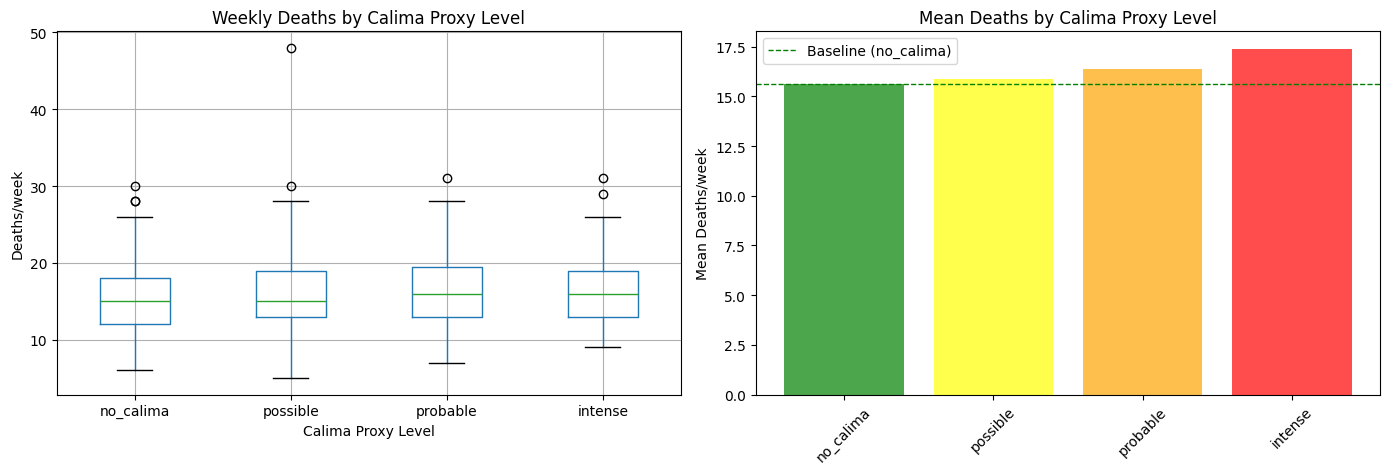

✅ Saved: eda_calima_deaths_by_level.png


In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Boxplot: deaths distribution by calima level
ax = axes[0]
plot_df = df.dropna(subset=['calima_proxy_level', 'deaths_week']).copy()
plot_df['calima_proxy_level'] = pd.Categorical(
    plot_df['calima_proxy_level'],
    categories=level_order,
    ordered=True
)
plot_df.boxplot(column='deaths_week', by='calima_proxy_level', ax=ax)
ax.set_title('Weekly Deaths by Calima Proxy Level')
ax.set_xlabel('Calima Proxy Level')
ax.set_ylabel('Deaths/week')
plt.sca(ax)
plt.xticks(rotation=0)

# 2. Bar chart: mean deaths by calima level
ax = axes[1]
means = deaths_by_level['mean'].reindex(level_order)
colors = ['green', 'yellow', 'orange', 'red']
ax.bar(range(len(level_order)), means.values, color=colors, alpha=0.7)
ax.set_xticks(range(len(level_order)))
ax.set_xticklabels(level_order, rotation=45)
ax.set_ylabel('Mean Deaths/week')
ax.set_title('Mean Deaths by Calima Proxy Level')
# Baseline reference line
ax.axhline(y=means['no_calima'], color='green', linestyle='--', linewidth=1, label='Baseline (no_calima)')
ax.legend()

fig.suptitle('')
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_calima_deaths_by_level.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: eda_calima_deaths_by_level.png")

## 6. Summary

In [13]:
# Compute strongest lag label
lag_values = {'lag0 (same week)': corr_lag0, 'lag1 (1 week prior)': corr_lag1, 'lag2 (2 weeks prior)': corr_lag2}
strongest_lag = max(lag_values, key=lambda k: abs(lag_values[k]))
strongest_corr = lag_values[strongest_lag]

# Compute Δ (intense vs possible) for summary
mean_possible = deaths_by_level.loc['possible', 'mean']
delta_vs_possible = intense - mean_possible

summary = pd.DataFrame({
    'Finding': [
        'Strongest lag (highest |r|)',
        'ANOVA F-statistic',
        'ANOVA p-value',
        'Effect size (η²)',
        'Δ deaths (intense vs no_calima)',
        'Δ deaths (intense vs possible)',
        'Sample size - intense weeks',
    ],
    'Value': [
        f'{strongest_lag} (r={strongest_corr:.3f})',
        f'{f_stat:.2f}',
        f'{p_value:.2e}',
        f'{eta_squared:.4f} ({"large" if eta_squared >= 0.14 else "medium" if eta_squared >= 0.06 else "small" if eta_squared >= 0.01 else "negligible"})',
        f'+{delta:.2f} deaths/week',
        f'+{delta_vs_possible:.2f} deaths/week',
        f'{len(groups[3])} weeks',
    ]
})

print("\n" + "="*70)
print(f"SUMMARY: Calima Proxy vs Deaths — {ISLAND_NAME.replace('_', ' ').title()}")
print("="*70 + "\n")
print(summary.to_string(index=False))

# Save
summary.to_csv(TAB_DIR / 'eda_calima_deaths_summary.csv', index=False)
print("\n✅ Saved: eda_calima_deaths_summary.csv")


SUMMARY: Calima Proxy vs Deaths — La Palma

                        Finding                          Value
    Strongest lag (highest |r|) lag2 (2 weeks prior) (r=0.117)
              ANOVA F-statistic                           1.03
                  ANOVA p-value                       3.79e-01
               Effect size (η²)            0.0059 (negligible)
Δ deaths (intense vs no_calima)              +1.76 deaths/week
 Δ deaths (intense vs possible)              +1.53 deaths/week
    Sample size - intense weeks                       20 weeks

✅ Saved: eda_calima_deaths_summary.csv
